# Previsão de inadimplência em cobranças mensais

A Datarisk quer identificar, com antecedência, quais cobranças mensais têm maior probabilidade de serem pagas com 5 dias ou mais de atraso em relação ao vencimento. Essa probabilidade será usada para acionar estratégias proativas de cobrança, priorizando o esforço de contato sobre os clientes mais arriscados.

## Resumo

1. **Target**: `ATRASO_DIAS = DATA_PAGAMENTO − DATA_VENCIMENTO`; `TARGET = 1` se `ATRASO_DIAS >= 5`, senão `0`.
2. **Validação fora do tempo (out-of-time)**: como o sistema roda mês a mês e a base de teste é posterior à de desenvolvimento, a validação usa os últimos 5 meses de desenvolvimento.
3. **Engenharia de atributos sem vazamento (leakage)**: todo atributo de comportamento passado (ex.: taxa histórica de atraso do cliente) é calculado usando apenas contratos cujo vencimento já havia ocorrido antes da emissão do contrato que está sendo avaliado, sendo a mesma regra vale tanto para treino/validação quanto para a base de teste.
4. **Modelo**: Gradient Boosting sobre árvores que lida com valores ausentes e variáveis categóricas.
5. **Métricas de avaliação**: AUC-ROC, KS (Kolmogorov–Smirnov) e PR-AUC/Brier -> métricas padrão de mercado para modelos de risco de crédito com alvo desbalanceado.
6. **Saída**: probabilidade de inadimplência.

## Sumário

1. Carregamento dos dados
2. Exploração inicial (EDA)
3. Construção da variável target
4. Engenharia de atributos (cadastro, informações mensais, comportamento histórico sem vazamento)
5. Estratégia de validação out-of-time
6. Modelagem
7. Avaliação do modelo
8. Treino final e geração das previsões para `base_pagamentos_teste.csv`
9. Conclusões, limitações e próximos passos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

DATA_DIR = Path("data")

## 1. Carregamento dos dados

In [2]:
cadastral = pd.read_csv(DATA_DIR/"base_cadastral.csv", parse_dates=["DATA_CADASTRO"], sep=';')
info = pd.read_csv(DATA_DIR/"base_info.csv", sep=';')
pagamentos_desenvolvimento = pd.read_csv(DATA_DIR/"base_pagamentos_desenvolvimento.csv", parse_dates=["DATA_EMISSAO_DOCUMENTO", "DATA_PAGAMENTO", "DATA_VENCIMENTO"], sep=';')
pagamentos_teste = pd.read_csv(DATA_DIR/"base_pagamentos_teste.csv", parse_dates=["DATA_EMISSAO_DOCUMENTO", "DATA_VENCIMENTO"], sep=';')

In [3]:
print('BASE CADASTRAL')
display(cadastral)

print('BASE INFO')
display(info)

print('BASE PAGAMENTOS DESENVOLVIMENTO')
display(pagamentos_desenvolvimento)

print('BASE PAGAMENTOS TESTE')
display(pagamentos_teste)

BASE CADASTRAL


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62
...,...,...,...,...,...,...,...,...
1310,3431426889924624821,2020-08-13,92,NaN,Serviços,HOTMAIL,MEDIO,69
1311,5288503299611498087,2020-11-03,NaN,NaN,Comércio,YAHOO,PEQUENO,13
1312,957773253650890560,2021-07-05,NaN,NaN,Comércio,GMAIL,MEDIO,20
1313,6094038865287329652,2021-07-05,NaN,NaN,Serviços,GMAIL,GRANDE,48


BASE INFO


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0
...,...,...,...,...
24396,705648002974742140,2021-12,278663.0,105.0
24397,4993499380140734678,2021-12,156968.0,140.0
24398,4614484019183480654,2021-12,292698.0,121.0
24399,1299146298565441811,2021-12,106180.0,121.0


BASE PAGAMENTOS DESENVOLVIMENTO


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99
...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99


BASE PAGAMENTOS TESTE


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99
...,...,...,...,...,...,...
12270,705648002974742140,2021-11,2021-11-25,2021-12-13,47010.00,6.99
12271,4993499380140734678,2021-11,2021-11-25,2021-12-13,122875.35,8.99
12272,4614484019183480654,2021-11,2021-11-26,2028-09-30,302200.00,5.99
12273,1299146298565441811,2021-11,2021-11-26,2021-12-13,143791.85,5.99


## 2. Exploração inicial (EDA)

Inicialmente vamos verificar o tamanho e o tipo dos dados e a quantidade de nulos de cada base, e do período (safra) coberto por desenvolvimento e por teste.

In [4]:
def resumo(df, nome):
    r = pd.DataFrame({"dtype": df.dtypes, "nulos": df.isnull().sum()})
    print(f"--- {nome} ---")
    print(r)
    print()


for nome, df in [
    ("base_cadastral", cadastral),
    ("base_info", info),
    ("base_pagamentos_desenvolvimento", pagamentos_desenvolvimento),
    ("base_pagamentos_teste", pagamentos_teste),
]:
    resumo(df, nome)

print()
print("Safra de desenvolvimento: de", pagamentos_desenvolvimento["SAFRA_REF"].min(), "até", pagamentos_desenvolvimento["SAFRA_REF"].max())
print("Safra de teste: de", pagamentos_teste["SAFRA_REF"].min(), "até", pagamentos_teste["SAFRA_REF"].max())

--- base_cadastral ---
                              dtype  nulos
ID_CLIENTE                    int64      0
DATA_CADASTRO        datetime64[ns]      0
DDD                          object    237
FLAG_PF                      object   1249
SEGMENTO_INDUSTRIAL          object     83
DOMINIO_EMAIL                object     30
PORTE                        object     41
CEP_2_DIG                    object      0

--- base_info ---
                      dtype  nulos
ID_CLIENTE            int64      0
SAFRA_REF            object      0
RENDA_MES_ANTERIOR  float64    717
NO_FUNCIONARIOS     float64   1252

--- base_pagamentos_desenvolvimento ---
                                 dtype  nulos
ID_CLIENTE                       int64      0
SAFRA_REF                       object      0
DATA_EMISSAO_DOCUMENTO  datetime64[ns]      0
DATA_PAGAMENTO          datetime64[ns]      0
DATA_VENCIMENTO         datetime64[ns]      0
VALOR_A_PAGAR                  float64   1170
TAXA                           fl

## 3. Construção da variável target

Inadimplente = pago com 5 dias ou mais de atraso em relação ao vencimento. Isso será calculado a partir da base de desenvolvimento, que tem `DATA_PAGAMENTO`.

`ATRASO_DIAS = DATA_PAGAMENTO − DATA_VENCIMENTO` (em dias corridos). `TARGET = 1` se `ATRASO_DIAS >= 5`; caso contrário `0`, incluindo pagamentos em dia, adiantados e com atraso pequeno (1 a 4 dias), todos tratados como adimplentes.

In [5]:
def criar_target(df):
    df = df.copy()
    df["ATRASO_DIAS"] = (df["DATA_PAGAMENTO"] - df["DATA_VENCIMENTO"]).dt.days
    df["TARGET"] = (df["ATRASO_DIAS"] >= 5).astype(int)
    return df

pagamentos_desenvolvimento = criar_target(pagamentos_desenvolvimento)

print("Média de inadimplência (base de desenvolvimento):", f"{pagamentos_desenvolvimento['TARGET'].mean():.2%}")
print()
print("Distribuição do atraso (dias):")
print(pagamentos_desenvolvimento["ATRASO_DIAS"].describe())

Média de inadimplência (base de desenvolvimento): 7.02%

Distribuição do atraso (dias):
count    77414.000000
mean        -0.171429
std         25.229477
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: ATRASO_DIAS, dtype: float64


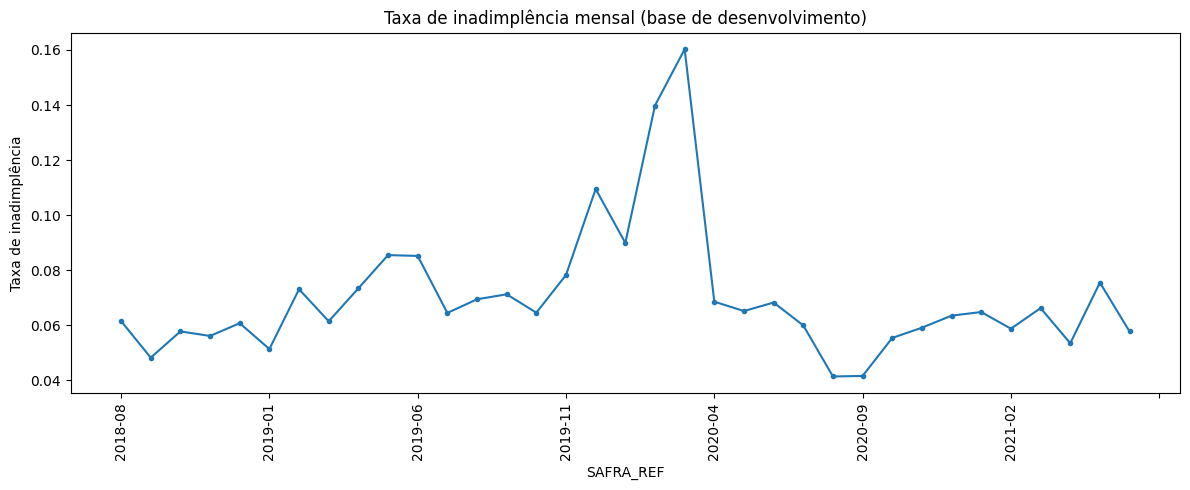

In [6]:
taxa_por_safra = pagamentos_desenvolvimento.groupby("SAFRA_REF")["TARGET"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
taxa_por_safra.plot(ax=ax, marker="o", markersize=3)
ax.set_ylabel("Taxa de inadimplência")
ax.set_xlabel("SAFRA_REF")
ax.set_title("Taxa de inadimplência mensal (base de desenvolvimento)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

A distribuição da target mostra um desbalanceamento, o que justifica avaliar o modelo com métricas mais robustas para problemas desbalanceados, como PR-AUC e Brier. Além disso, vale verificar como as variáveis numéricas se relacionam com o alvo antes de entrar na modelagem final.


In [7]:
vars_num = [
    "VALOR_A_PAGAR", "TAXA", "PRAZO_DIAS", "DIAS_RELACIONAMENTO",
    "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS", "HIST_N_CONTRATOS", "HIST_TAXA_INADIMPLENCIA"
]
vars_num = [col for col in vars_num if col in pagamentos_desenvolvimento.columns]

print("Taxa geral de inadimplência:", f"{pagamentos_desenvolvimento['TARGET'].mean():.2%}")
print()
print("Correlação linear com a target (variáveis numéricas):")
if len(vars_num) > 0:
    correlacoes = pd.Series({col: pagamentos_desenvolvimento[col].corr(pagamentos_desenvolvimento['TARGET']) for col in vars_num}).sort_values(ascending=False)
    print(correlacoes.to_string())
else:
    print("As features numéricas ainda não foram criadas neste ponto da pipeline.")
print()
print("Resumo por safra:")
display(pagamentos_desenvolvimento.groupby('SAFRA_REF')['TARGET'].mean().sort_index())

Taxa geral de inadimplência: 7.02%

Correlação linear com a target (variáveis numéricas):
TAXA             0.011899
VALOR_A_PAGAR   -0.088203

Resumo por safra:


SAFRA_REF
2018-08    0.061492
2018-09    0.048193
2018-10    0.057729
2018-11    0.056079
2018-12    0.060709
2019-01    0.051327
2019-02    0.073059
2019-03    0.061415
2019-04    0.073372
2019-05    0.085455
2019-06    0.085164
2019-07    0.064447
2019-08    0.069402
2019-09    0.071218
2019-10    0.064529
2019-11    0.078250
2019-12    0.109477
2020-01    0.089892
2020-02    0.139819
2020-03    0.160282
2020-04    0.068539
2020-05    0.065126
2020-06    0.068226
2020-07    0.059904
2020-08    0.041352
2020-09    0.041562
2020-10    0.055371
2020-11    0.059085
2020-12    0.063465
2021-01    0.064772
2021-02    0.058714
2021-03    0.066208
2021-04    0.053435
2021-05    0.075464
2021-06    0.057700
Name: TARGET, dtype: float64

Há um pico  de inadimplência em 2020-02/2020-03 (de 6% para 16%), coincidindo com o início da pandemia de COVID-19 no Brasil, seguido de retorno ao patamar histórico em poucos meses. Pelo gráfico, podemos ver que o comportamento de pagamento é sensível a choques macroeconômicos.

## 4. Engenharia de atributos

Vamos montar, para cada cobrança, quatro grupos de atributos:

1. **Do contrato**: valor a pagar, taxa e prazo (`DATA_VENCIMENTO − DATA_EMISSAO_DOCUMENTO`).
2. **Cadastrais** (`base_cadastral`): tempo de relacionamento do cliente, se é PF/PJ, segmento, porte, domínio de e-mail, DDD e CEP.
3. **Mensais** (`base_info`): renda e nº de funcionários do mês anterior.
4. **Comportamento histórico do cliente**: taxa de inadimplência e nº de contratos anteriores

In [8]:
features = ["DDD", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE", "CEP_2_DIG"]


def preparar_cadastral(df):
    out = df.merge(cadastral, on="ID_CLIENTE", how="left")
    out["DIAS_RELACIONAMENTO"] = (out["DATA_EMISSAO_DOCUMENTO"] - out["DATA_CADASTRO"]).dt.days
    for col in features:
        out[col] = out[col].fillna("MISSING").astype(str).astype("category")
    return out


def adicionar_atributos_mensais_e_prazo(df, info_df):
    df = df.merge(info_df, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
    df["PRAZO_DIAS"] = (df["DATA_VENCIMENTO"] - df["DATA_EMISSAO_DOCUMENTO"]).dt.days
    return df


def criar_historico_sem_vazamento(df):
    df = df.sort_values(["ID_CLIENTE", "DATA_EMISSAO_DOCUMENTO"]).copy()
    df["HIST_N_CONTRATOS"] = df.groupby("ID_CLIENTE").cumcount()
    df["HIST_TAXA_INADIMPLENCIA"] = df.groupby("ID_CLIENTE")["TARGET"].transform(
        lambda s: s.shift().expanding().mean()
    )
    return df


pagamentos_desenvolvimento = preparar_cadastral(pagamentos_desenvolvimento)
pagamentos_teste = preparar_cadastral(pagamentos_teste)

pagamentos_desenvolvimento = adicionar_atributos_mensais_e_prazo(pagamentos_desenvolvimento, info)
pagamentos_teste = adicionar_atributos_mensais_e_prazo(pagamentos_teste, info)

pagamentos_desenvolvimento = criar_historico_sem_vazamento(pagamentos_desenvolvimento)

# para o teste: resumo do histórico completo de cada cliente em desenvolvimento
resumo_cliente = (
    pagamentos_desenvolvimento.groupby("ID_CLIENTE")
    .agg(
        HIST_N_CONTRATOS=("TARGET", "count"),
        HIST_TAXA_INADIMPLENCIA=("TARGET", "mean"),
    )
    .reset_index()
)
pagamentos_teste = pagamentos_teste.merge(resumo_cliente, on="ID_CLIENTE", how="left")

### histórico do cliente sem olhar pro futuro

Para calcular o histórico do cliente, teríamos que considerar contratos que já venceram antes do contrato que está sendo avaliado no momento, uma vez que ao deixar entrar um contrato futuro nessa conta, o modelo verá uma informação que na prática ele não teria disponível no momento de fazer a previsão real.

Para resolver isso no pandas, ordenamos os contratos de cada cliente por data de emissão e usamos `.shift()` junto com `.expanding().mean()`: o `shift()` tira o contrato atual da conta (olha só para trás), e o `expanding()` vai calculando a média acumulada de tudo que veio antes dele.

Para base de teste: como todos os contratos de `base_pagamentos_desenvolvimento` são antes de julho/2021 (quando a base de teste começa), é possível calcular a taxa de inadimplência histórica de cada cliente em cima de toda a base de desenvolvimento e usar esse número em todas as cobranças de teste daquele cliente.

Para evitar viés indevido e manter a solução alinhada com boas práticas de crédito, a variável PF/PJ não foi usada como feature de treinamento. O objetivo aqui é avaliar risco com base em características do contrato, do cadastro e do histórico do cliente, sem depender de atributos sensíveis que podem introduzir injustiças ou problemas regulatórios.


In [9]:
# validação do histórico criado de forma consistente e sem vazamento
print("% dos primeiros contratos de clientes na base de desenvolvimento (sem histórico):", f"{(pagamentos_desenvolvimento.HIST_N_CONTRATOS == 0).mean():.1%}")
print("% de clientes de teste sem nenhum histórico em desenvolvimento:", f"{pagamentos_teste.HIST_N_CONTRATOS.isna().mean():.1%}")
print()
print(pagamentos_desenvolvimento[["ID_CLIENTE", "DATA_EMISSAO_DOCUMENTO", "TARGET", "HIST_N_CONTRATOS", "HIST_TAXA_INADIMPLENCIA"]].head(10))

% dos primeiros contratos de clientes na base de desenvolvimento (sem histórico): 1.6%
% de clientes de teste sem nenhum histórico em desenvolvimento: 1.9%

            ID_CLIENTE DATA_EMISSAO_DOCUMENTO  TARGET  HIST_N_CONTRATOS  \
166   8784237149961904             2018-08-17       0                 0   
167   8784237149961904             2018-08-22       0                 1   
168   8784237149961904             2018-08-23       0                 2   
169   8784237149961904             2018-08-23       0                 3   
170   8784237149961904             2018-08-24       0                 4   
171   8784237149961904             2018-09-04       0                 5   
172   8784237149961904             2018-09-06       0                 6   
173   8784237149961904             2018-09-09       0                 7   
174   8784237149961904             2018-09-11       0                 8   
2794  8784237149961904             2018-09-17       0                 9   

      HIST_TAXA_I

In [10]:
feature_cols = [
    "VALOR_A_PAGAR", "TAXA", "PRAZO_DIAS",
    "DIAS_RELACIONAMENTO", "DDD", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE", "CEP_2_DIG",
    "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS",
    "HIST_N_CONTRATOS", "HIST_TAXA_INADIMPLENCIA",
]

pagamentos_desenvolvimento[feature_cols].head()

# análise de correlação após a engenharia de atributos
vars_num = [
    "VALOR_A_PAGAR", "TAXA", "PRAZO_DIAS", "DIAS_RELACIONAMENTO",
    "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS", "HIST_N_CONTRATOS", "HIST_TAXA_INADIMPLENCIA"
]
vars_num = [col for col in vars_num if col in pagamentos_desenvolvimento.columns]

print("Correlação linear com a target (variáveis numéricas após a engenharia de atributos):")
correlacoes = pd.Series({col: pagamentos_desenvolvimento[col].corr(pagamentos_desenvolvimento['TARGET']) for col in vars_num}).sort_values(ascending=False)
print(correlacoes.to_string())

Correlação linear com a target (variáveis numéricas após a engenharia de atributos):
HIST_TAXA_INADIMPLENCIA    0.509653
PRAZO_DIAS                 0.106617
TAXA                       0.011899
HIST_N_CONTRATOS           0.009016
NO_FUNCIONARIOS           -0.017179
DIAS_RELACIONAMENTO       -0.036033
RENDA_MES_ANTERIOR        -0.067847
VALOR_A_PAGAR             -0.088203


## 5. Divisão treino/validação (out-of-time)

Como a base de teste é sempre posterior à de desenvolvimento (o sistema roda mês a mês, prevendo o futuro), separamos os últimos 5 meses de desenvolvimento (`2021-02` a `2021-06`) como validação, simulando um "futuro" e treinamos com todo o resto.

In [11]:
SAFRA_CORTE = "2021-02"  # a partir daqui é validação. Antes disso é treino

treino = pagamentos_desenvolvimento[pagamentos_desenvolvimento["SAFRA_REF"] < SAFRA_CORTE]
validacao = pagamentos_desenvolvimento[pagamentos_desenvolvimento["SAFRA_REF"] >= SAFRA_CORTE]

X_treino, y_treino = treino[feature_cols], treino["TARGET"]
X_val, y_val = validacao[feature_cols], validacao["TARGET"]

print(f"Treino: {len(X_treino)} linhas; taxa de inadimplência {y_treino.mean():.2%}")
print(f"Validação: {len(X_val)} linhas; taxa de inadimplência {y_val.mean():.2%}")

Treino: 65540 linhas; taxa de inadimplência 7.16%
Validação: 11874 linhas; taxa de inadimplência 6.25%


A avaliação mais sólida começa com um baseline simples, para mostrar que o modelo realmente agrega valor em relação a uma previsão ingênua baseada apenas na taxa média de inadimplência.


In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss


def avaliar_metricas(y_true, probs):
    return {
        "AUC-ROC": roc_auc_score(y_true, probs),
        "PR-AUC": average_precision_score(y_true, probs),
        "Brier": brier_score_loss(y_true, probs),
    }

baseline = DummyClassifier(strategy="prior")
baseline.fit(X_treino[feature_cols], y_treino)
pred_baseline = baseline.predict_proba(X_val[feature_cols])[:, 1]

print("Baseline (taxa média de inadimplência):")
for nome, valor in avaliar_metricas(y_val, pred_baseline).items():
    print(f"- {nome}: {valor:.4f}")

Baseline (taxa média de inadimplência):
- AUC-ROC: 0.5000
- PR-AUC: 0.0625
- Brier: 0.0587


## 6. Modelagem

Usamos o `HistGradientBoostingClassifier` do scikit-learn (Gradient Boosting sobre árvores). Ele lida com valores ausentes e com variáveis categóricas, ou seja, não precisamos imputar `RENDA_MES_ANTERIOR` nem fazer one-hot encoding de `PORTE`, `CEP_2_DIG` etc.

O `early_stopping=True` escolhe sozinho quantas árvores usar (separando automaticamente uma fração do treino para isso). Em seguida avaliamos o resultado na validação out-of-time (`X_val`/`y_val`), que o modelo nunca viu.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

modelo = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    categorical_features=features,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    scoring="roc_auc",
    random_state=42,
)
modelo.fit(X_treino, y_treino)

print("Número de árvores escolhido pelo early stopping:", modelo.n_iter_)

Número de árvores escolhido pelo early stopping: 500


## 7. Avaliação do modelo

Como o alvo é desbalanceado (cerca de 7% de inadimplência), o objetivo é ranquear clientes por risco. Assim, usamos métricas padrão de mercado para modelos de risco de crédito:

- **AUC-ROC**: capacidade de separar bons e maus pagadores.
- **KS (Kolmogorov–Smirnov)**: distância máxima entre a distribuição de score de quem paga em dia e de quem atrasa.
- **PR-AUC (average precision)** e **Brier score**: complementam a AUC-ROC olhando para precisão/recall e para a calibração da probabilidade, o que é mais sensível ao desbalanceamento.

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve
from scipy.stats import ks_2samp

pred_val = modelo.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, pred_val)
pr_auc = average_precision_score(y_val, pred_val)
brier = brier_score_loss(y_val, pred_val)
ks = ks_2samp(pred_val[y_val == 1], pred_val[y_val == 0]).statistic

print(f"AUC-ROC: {auc:.4f}")
print(f"KS: {ks:.4f}")
print(f"PR-AUC: {pr_auc:.4f} (baseline = taxa de inadimplência = {y_val.mean():.4f})")
print(f"Brier score: {brier:.4f} (quanto menor, melhor)")

AUC-ROC: 0.9343
KS: 0.7730
PR-AUC: 0.5774 (baseline = taxa de inadimplência = 0.0625)
Brier score: 0.0373 (quanto menor, melhor)


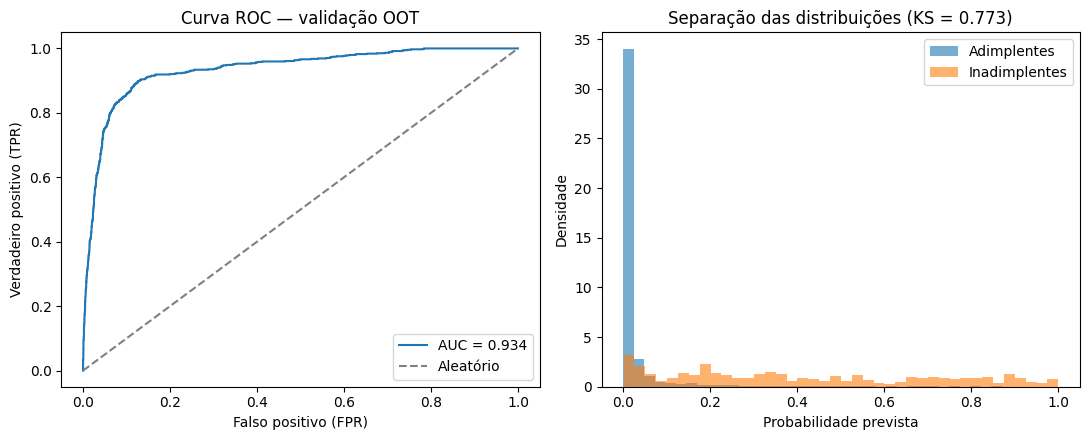

In [15]:
fpr, tpr, _ = roc_curve(y_val, pred_val)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Aleatório")
axes[0].set_xlabel("Falso positivo (FPR)")
axes[0].set_ylabel("Verdadeiro positivo (TPR)")
axes[0].set_title("Curva ROC — validação OOT")
axes[0].legend()

axes[1].hist(pred_val[y_val == 0], bins=40, alpha=0.6, density=True, label="Adimplentes")
axes[1].hist(pred_val[y_val == 1], bins=40, alpha=0.6, density=True, label="Inadimplentes")
axes[1].set_xlabel("Probabilidade prevista")
axes[1].set_ylabel("Densidade")
axes[1].set_title(f"Separação das distribuições (KS = {ks:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

Top 10 variáveis por importância (permutation importance):
HIST_TAXA_INADIMPLENCIA    0.080384
VALOR_A_PAGAR              0.059827
PRAZO_DIAS                 0.027963
CEP_2_DIG                  0.019918
DDD                        0.013740
DIAS_RELACIONAMENTO        0.007224
HIST_N_CONTRATOS           0.005002
NO_FUNCIONARIOS            0.000817
PORTE                      0.000555
DOMINIO_EMAIL              0.000382



AUC com as variáveis selecionadas: 0.9350
AUC com o modelo completo: 0.9343


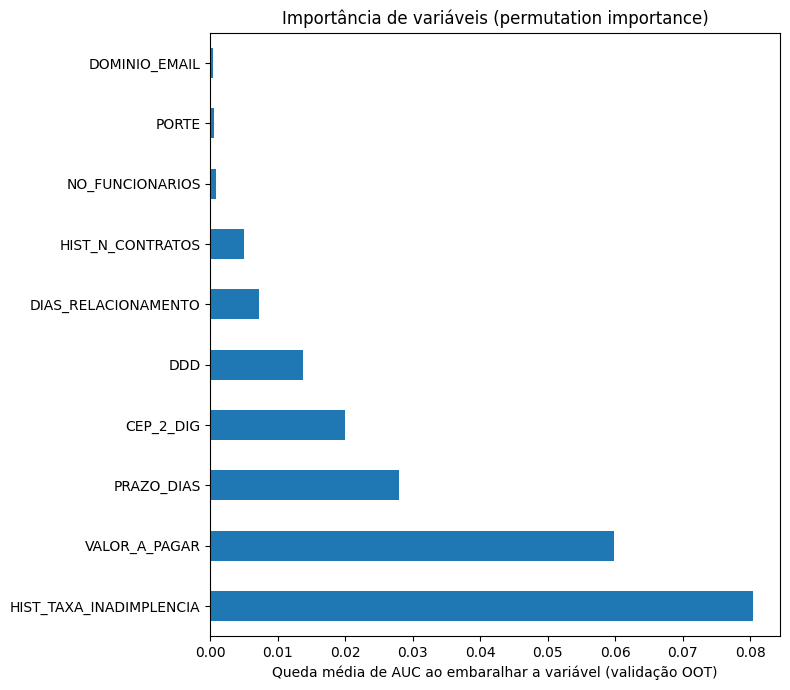

In [16]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(modelo, X_val, y_val, n_repeats=5, random_state=42, scoring="roc_auc", n_jobs=-1)
importancia = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

print("Top 10 variáveis por importância (permutation importance):")
print(importancia.head(10).to_string())
print()

# seleção de variáveis: treinamos um modelo reduzido com as variáveis mais importantes
selected_features = importancia.head(8).index.tolist()
cat_selected = [c for c in features if c in selected_features]

modelo_selecao = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    categorical_features=cat_selected,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    scoring="roc_auc",
    random_state=42,
)
modelo_selecao.fit(X_treino[selected_features], y_treino)
pred_selecao = modelo_selecao.predict_proba(X_val[selected_features])[:, 1]

print(f"AUC com as variáveis selecionadas: {roc_auc_score(y_val, pred_selecao):.4f}")
print(f"AUC com o modelo completo: {auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 7))
importancia.head(10).plot(kind="barh", ax=ax)
ax.set_xlabel("Queda média de AUC ao embaralhar a variável (validação OOT)")
ax.set_title("Importância de variáveis (permutation importance)")
plt.tight_layout()
plt.show()

O modelo atinge AUC $\approx$ 0.93 e KS $\approx$ 0.77 na validação out-of-time, valores muito bons para um modelo de crédito. As variáveis mais relevantes são o **valor da cobrança** (`VALOR_A_PAGAR`), a **região** (`CEP_2_DIG`, `DDD`) e o **prazo do contrato** (`PRAZO_DIAS`), seguidas pela **taxa histórica de inadimplência do cliente**. Isso é consistente já que contratos maiores/mais longos concentram mais risco, e diferenças regionais no cadastro de clientes carregam informação de risco.

O experimento de remover os atributos `HIST_` mostra que eles trazem um ganho, mesmo que modesto, de AUC, o que confirma que vale a pena mantê-los.

In [17]:
# Quanto os atributos comportamentais realmente agregam?
cols_sem_hist = [c for c in feature_cols if not c.startswith("HIST_")]
cat_sem_hist = [c for c in features if c in cols_sem_hist]

modelo_sem_hist = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_depth=6,
    categorical_features=cat_sem_hist,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=30,
    scoring="roc_auc", random_state=42,
)
modelo_sem_hist.fit(X_treino[cols_sem_hist], y_treino)
pred_sem_hist = modelo_sem_hist.predict_proba(X_val[cols_sem_hist])[:, 1]

print(f"AUC sem atributos comportamentais: {roc_auc_score(y_val, pred_sem_hist):.4f}")
print(f"AUC com atributos comportamentais: {auc:.4f}")

AUC sem atributos comportamentais: 0.9267
AUC com atributos comportamentais: 0.9343


Pelo gráfico de importância, `VALOR_A_PAGAR`, `CEP_2_DIG`, `PRAZO_DIAS` e `DDD` são as variáveis que mais pesam no modelo, já que contratos maiores/mais longos tendem a concentrar mais risco, e a região do cliente acaba carregando informação. Os atributos de histórico aparecem depois, mas o teste sem eles mostra que ainda ajudam um pouco (a AUC cai), então vale manter.

## 8. Treino final e geração das previsões

Com o modelo validado, retreinamos usando todo o histórico de desenvolvimento (treino + validação), já que mais dados tendem a gerar um modelo melhor e é a versão que vai realmente prever a base de teste. Fixamos o número de árvores no valor encontrado na validação (`modelo.n_iter_`) para o resultado ser reprodutível.

In [18]:
X_full, y_full = pagamentos_desenvolvimento[feature_cols], pagamentos_desenvolvimento["TARGET"]

modelo_final = HistGradientBoostingClassifier(
    max_iter=modelo.n_iter_,
    learning_rate=0.05,
    max_depth=6,
    categorical_features=features,
    early_stopping=False,
    random_state=42,
)
modelo_final.fit(X_full, y_full)

print("Modelo final treinado com", len(X_full), "linhas e", modelo_final.n_iter_, "árvores.")

Modelo final treinado com 77414 linhas e 500 árvores.


In [19]:
X_teste = pagamentos_teste[feature_cols]
proba_teste = modelo_final.predict_proba(X_teste)[:, 1]

print("Linhas em base_pagamentos_teste.csv:", len(pagamentos_teste))
print("Previsões geradas:", len(proba_teste))
print(f"Probabilidade média prevista: {proba_teste.mean():.2%}")
print(f"Probabilidade mínima: {proba_teste.min():.4f}")
print(f"Probabilidade máxima: {proba_teste.max():.4f}")

Linhas em base_pagamentos_teste.csv: 12275
Previsões geradas: 12275
Probabilidade média prevista: 4.29%
Probabilidade mínima: 0.0000
Probabilidade máxima: 0.9973


In [20]:
submissao = pagamentos_teste[["ID_CLIENTE", "SAFRA_REF"]].copy()
submissao["PROBABILIDADE_INADIMPLENCIA"] = proba_teste

assert list(submissao.columns) == ["ID_CLIENTE", "SAFRA_REF", "PROBABILIDADE_INADIMPLENCIA"]
assert len(submissao) == len(pagamentos_teste)

submissao.to_csv("submissao_case.csv", index=False)
submissao.head()

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.001747
1,274692171162531764,2021-07,0.008233
2,274692171162531764,2021-07,0.008379
3,274692171162531764,2021-07,0.008379
4,465309249432033993,2021-07,0.001518


## 9. Conclusões, limitações e próximos passos

**Resultado**: o modelo final atinge AUC-ROC $\approx$ 0.93 e KS $\approx$ 0.77 na validação out-of-time (5 meses à frente do treino). As previsões para `base_pagamentos_teste.csv` foram salvas em `submissao_case.csv`.

**Limitações**: cerca de 2% dos clientes de teste são novos (sem histórico em desenvolvimento) e uma parte das linhas não tem match em `base_info`. Nesses casos o modelo depende mais dos atributos cadastrais e do contrato em si. Também encontramos valores de `DDD` corrompidos na base cadastral e tratamos como uma categoria à parte, sem tentar reconstruir o valor original.

**Próximos passos**: se isso fosse pra produção: acompanhar AUC/KS mês a mês conforme os desfechos reais forem sendo conhecidos (para pegar se o modelo começar a piorar com o tempo), e retreinar periodicamente incorporando as safras mais recentes.